In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import sparse, integrate

import warnings
warnings.filterwarnings('ignore')    #suppress warnings

## The **time-dependent Schrödinger equation**  :

$ \qquad\qquad\displaystyle i \hbar \frac{\partial \psi(x,t)}{\partial t} = -\frac{\hbar^2}{2m} \nabla^2 \psi(x,t)  + V(x) \psi(x,t)$

Where,

* $ \psi(x,t) $ is the **wave function**.
* $ \hbar $ is **reduced Planck's constant**.
* $ m $ is the **particle mass**.
* $ V(x) $ is the **potential energy**.
* $ i $ is the **imaginary unit**.
* Delta Function $\qquad\displaystyle{\nabla \equiv \Big( \frac{\partial}{\partial x}\hat{i} + \frac{\partial}{\partial y}\hat{j} + \frac{\partial}{\partial z}\hat{k} \Big)}$
 

### Laplace Operator (Finite Difference)

The 1-D Laplace operator $\displaystyle\nabla^2=\frac{\partial^2}{\partial x^2}$ can be expressed in terms of a banded matrix :

$\begin{align}
\frac{\partial^2}{\partial x^2} \psi(x)
&= 
\frac{1}{dx} \left[ \frac{\psi_{n+1} - \psi_{n}}{dx} - \frac{\psi_{n} - \psi_{n-1}}{dx} \right]
\\
&=
\frac{\psi_{n+1} - 2 \psi_{n} + \psi_{n-1}}{(dx)^2} 
\\
&=
\frac{1}{(dx)^2}
\begin{pmatrix}
  -2  &  1  &  0  &  \cdots & 0 &  0 \\
   1  & -2  &  1  &  \cdots & 0 &  0 \\
   0  &  1  & -2  &  \cdots & 1 &  0 \\
   0  &  0  &  1  &  \ddots & -2 &  1 \\
   0  &  0  &  0  &  \cdots & 1 & -2 
\end{pmatrix}
\cdot
\begin{pmatrix}
   \psi_1   \\
   \psi_2   \\
   \psi_3   \\
   \vdots   \\
   \psi_n  
\end{pmatrix}
\\
&\equiv
\mathbf{D2} \cdot \psi
\end{align}$


The **finite difference second-derivative operator**  defined as a matrix can be written as :

$ \qquad\qquad\displaystyle
D_2 = \frac{1}{\Delta x^2}
\begin{bmatrix}
  -2   &    1   &   0   &  \cdots &  0 \\
   1   &   -2   &   1   &  \cdots &  0 \\
   0   &    1   &  -2   &  \cdots &  0 \\
\vdots & \vdots & \vdots & \ddots &  1 \\
   0   &    0   &    0   &   1    & -2
\end{bmatrix}_{\text{len}(x)\times\text{len}(x)} \qquad\leftarrow {\large\frac{\partial^2}{\partial x^2}}$

Where,

* $ \Delta x $ is the **spatial step size**.
* The diagonal elements are $-2 / \Delta x^2$.
* The off-diagonal elements (just above and below the diagonal) are $1 / \Delta x^2$.

The **initial Gaussian wave packet**

$ \qquad\qquad\displaystyle \psi_0(x) = \sqrt{\frac{1}{\sigma \sqrt{\pi}}} \; \exp\Bigg[-\frac{(x - x_0)^2}{2 \sigma^2} \Bigg] \; \exp(i k_x x)$

Where,

* $ \sigma $ is the **width** of the Gaussian.
* $ x_0 $ is the **center** of the wave packet.
* $ k_x $ is the **wave number**, controlling the momentum of the packet.
* $ A $ is the **normalization constant** ensuring $ \int |\psi_0(x)|^2 dx = 1$.


In [2]:
def psi_t(t, psi, D2, V):            # Solve the Initial Value Problem
    hbar = 1       
    return -1j * (- 0.5 * hbar / m * D2(x, dx).dot(psi) + V(x) / hbar * psi)

def D2(x, dx):
    return sparse.diags([1, -2, 1], [-1, 0, 1], shape=(x.size, x.size)) / dx**2

def psi0(x,kx = 50,m = 1,sigma = 0.5,x0 = 2):
    A = 1.0 / (sigma * np.sqrt(np.pi))
    return np.sqrt(A) * np.exp(-(x-x0)**2 / (2*sigma**2)) * np.exp(1j * kx * x)

In [3]:
dx = 0.01
x_last = 8
x = np.arange(0, x_last + dx, dx)

# --- Wave packet parameters ---
kx = 50
m = 1
sigma = 0.5
x0 = 2

dt = 0.01
t0 = 0.0
tf = 0.16
t_eval = np.arange(t0, tf+dt, dt)

# Potential Step (right)

$V(x) = \begin{cases} 0 & x < a \\ V_0 & x > a \end{cases}$

<Figure size 1000x600 with 0 Axes>

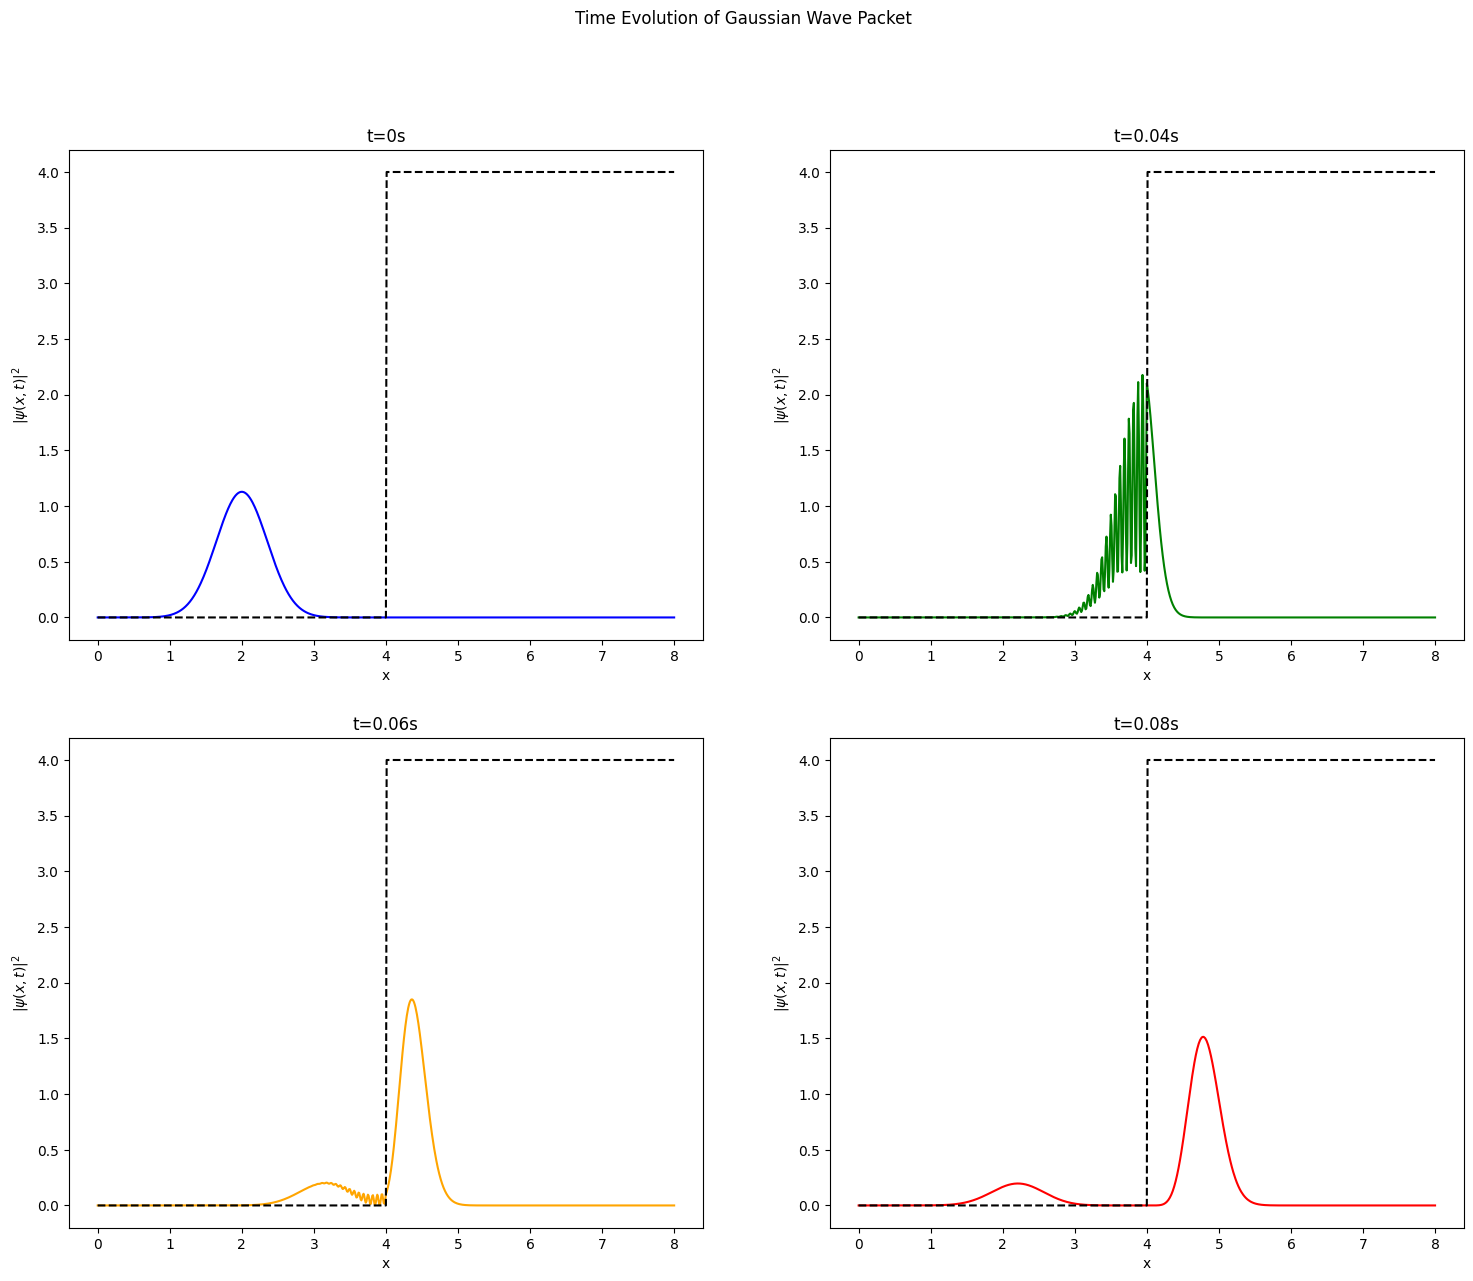

In [4]:
def V(x):
    V_hight = 1000
    V = np.zeros(x.shape)
    for i, _x in enumerate(x):
        if _x > 4:
           V[i] = V_hight
    return V

psi_initial=psi0(x)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))

plt.figure(figsize=(10,6))

times_to_plot = [0, 0.04, 0.06, 0.08]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple']

fig, axes = plt.subplots(2,2, figsize=(18,14))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.004, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
fig.suptitle('Time Evolution of Gaussian Wave Packet')
plt.show()

# Potential Step (left)

$V(x) = \begin{cases} 0 & x > a \\ V_0 & x < a \end{cases}$

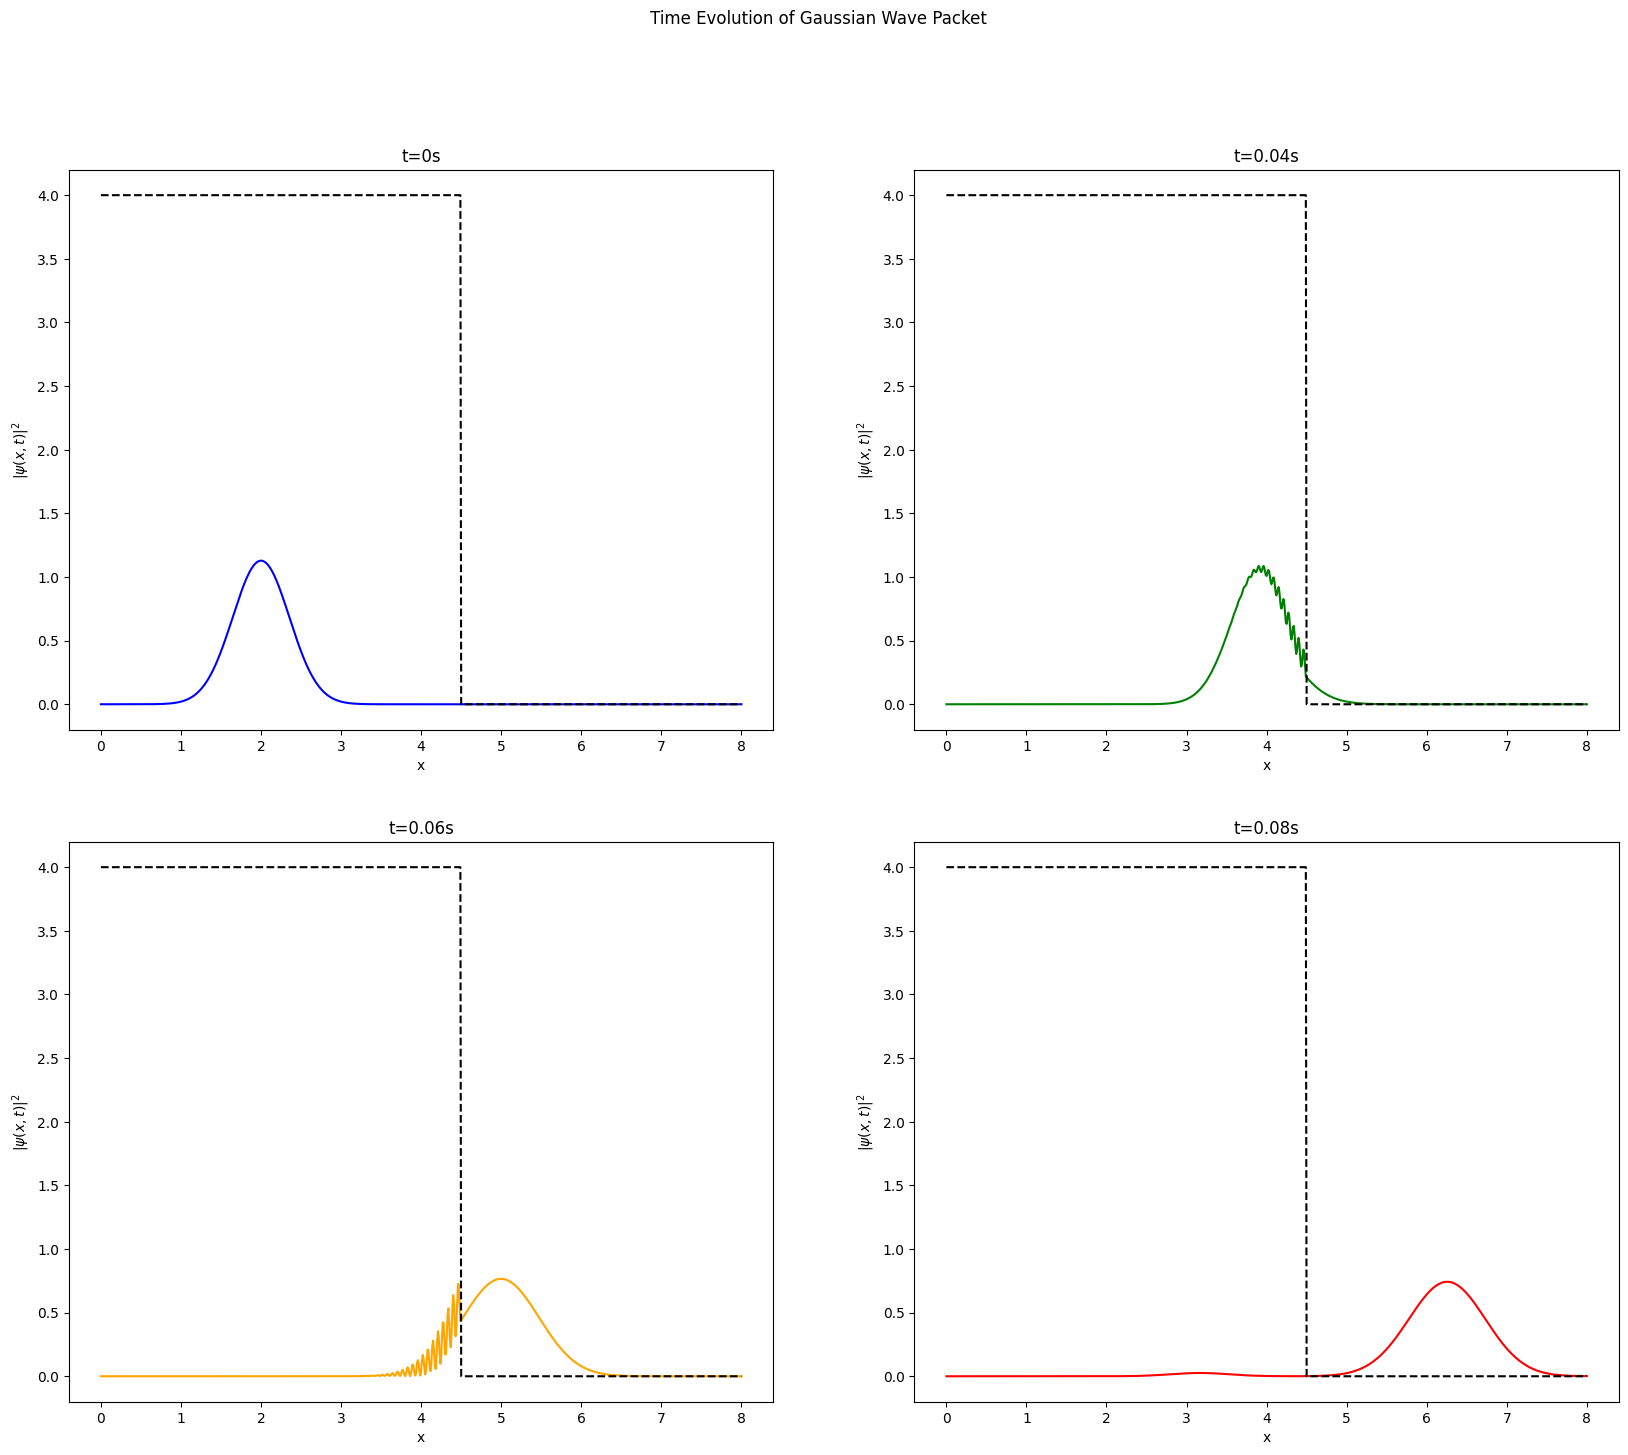

In [5]:
def V(x):
    V_hight = 1000
    V = np.zeros(x.shape)
    for i, _x in enumerate(x):
        if _x < 4.5:
           V[i] = V_hight
    return V
    

psi_initial=psi0(x)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))

times_to_plot = [0, 0.04, 0.06, 0.08]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple']

fig, axes = plt.subplots(2,2, figsize=(20,16))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.004, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
fig.suptitle('Time Evolution of Gaussian Wave Packet')
plt.show()

# Potential Barrier

$ V(x) =\left\{\begin{array}{rl} 0 & \text{if }0\le x\le a, \\ V_0 & \text{if }a\le x\le b, \\ 0 & \text{if }b\le x\le L, \\\infty & \text{otherwise }. \end{array} \right. $

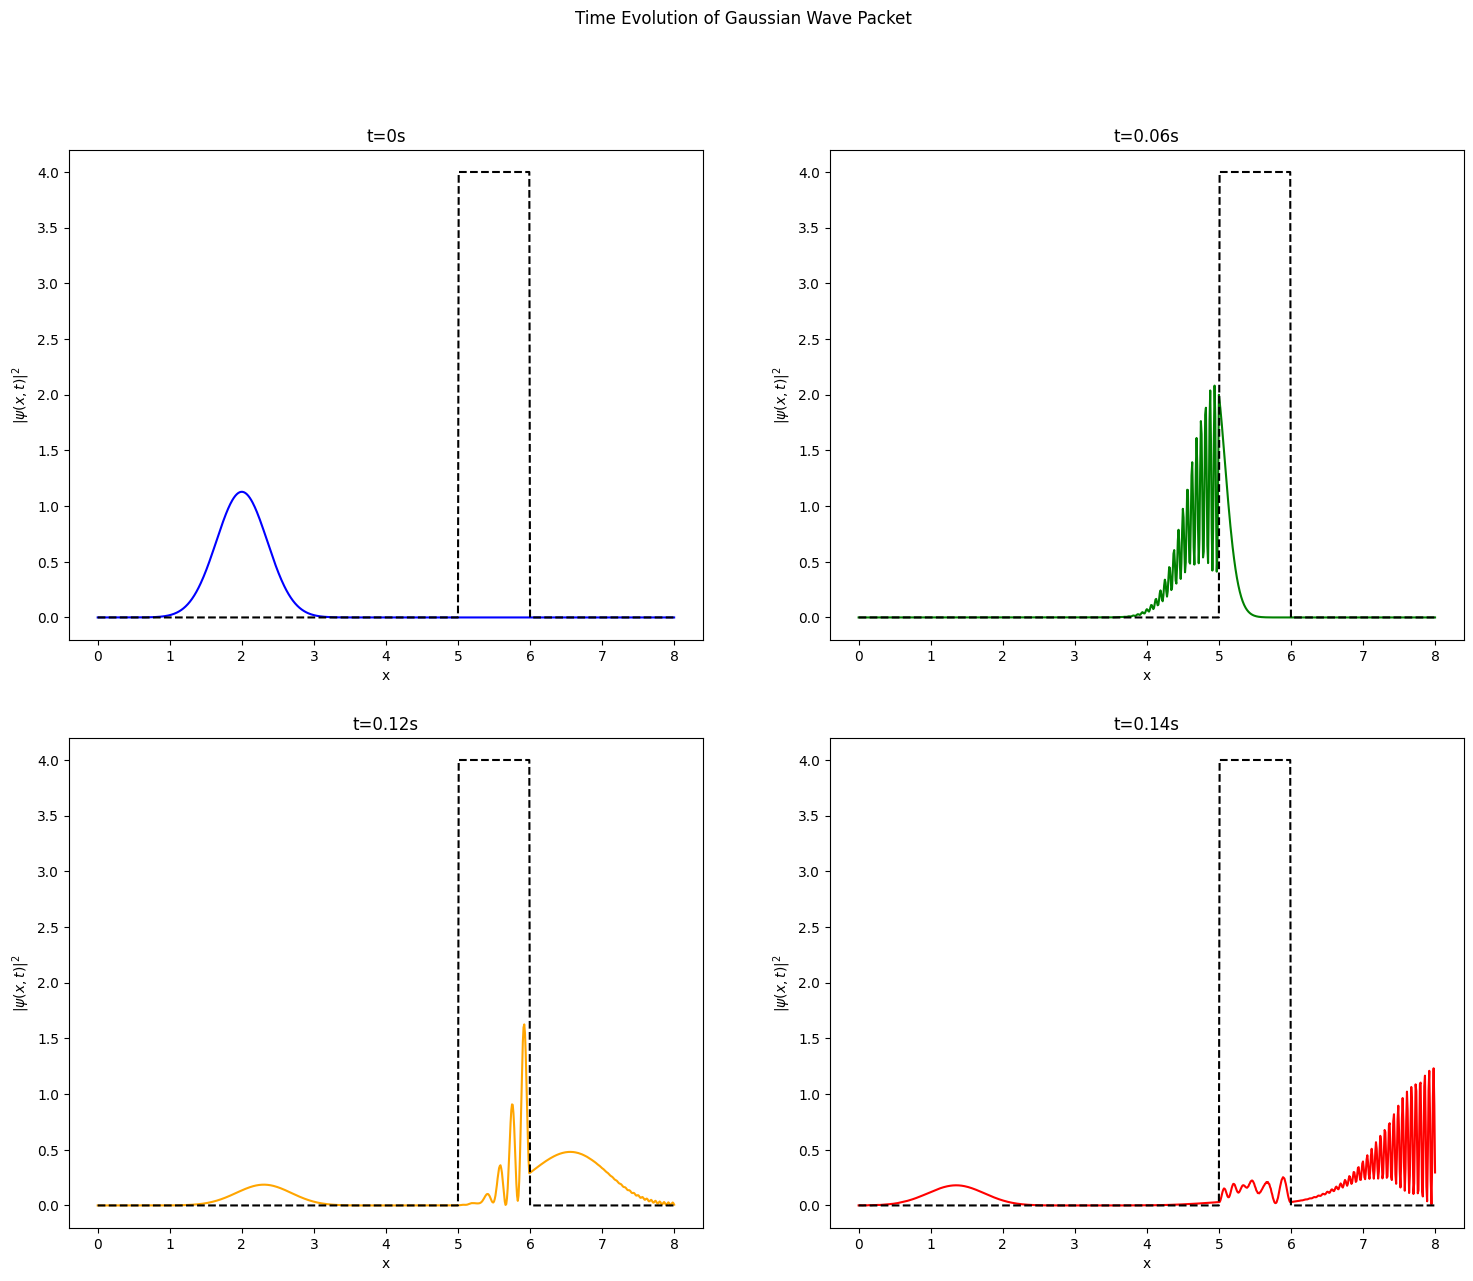

In [6]:
def V(x):
    V_height = 1000
    V = np.zeros_like(x)
    V[(x>5) & (x<6)] = V_height
    return V
    
psi_initial=psi0(x)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))


times_to_plot = [0, 0.06, 0.12, 0.14]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple']

fig, axes = plt.subplots(2,2, figsize=(18, 14))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.004, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
fig.suptitle('Time Evolution of Gaussian Wave Packet')
#plt.legend()
plt.show()

# Infinite Potential Well

$ V(x) =\left\{\begin{array}{rl} \infty & \text{if }0\le x\le a, \\ 0 & \text{if }a\le x\le b, \\ \infty & \text{otherwise }. \end{array} \right. $

<Figure size 1000x600 with 0 Axes>

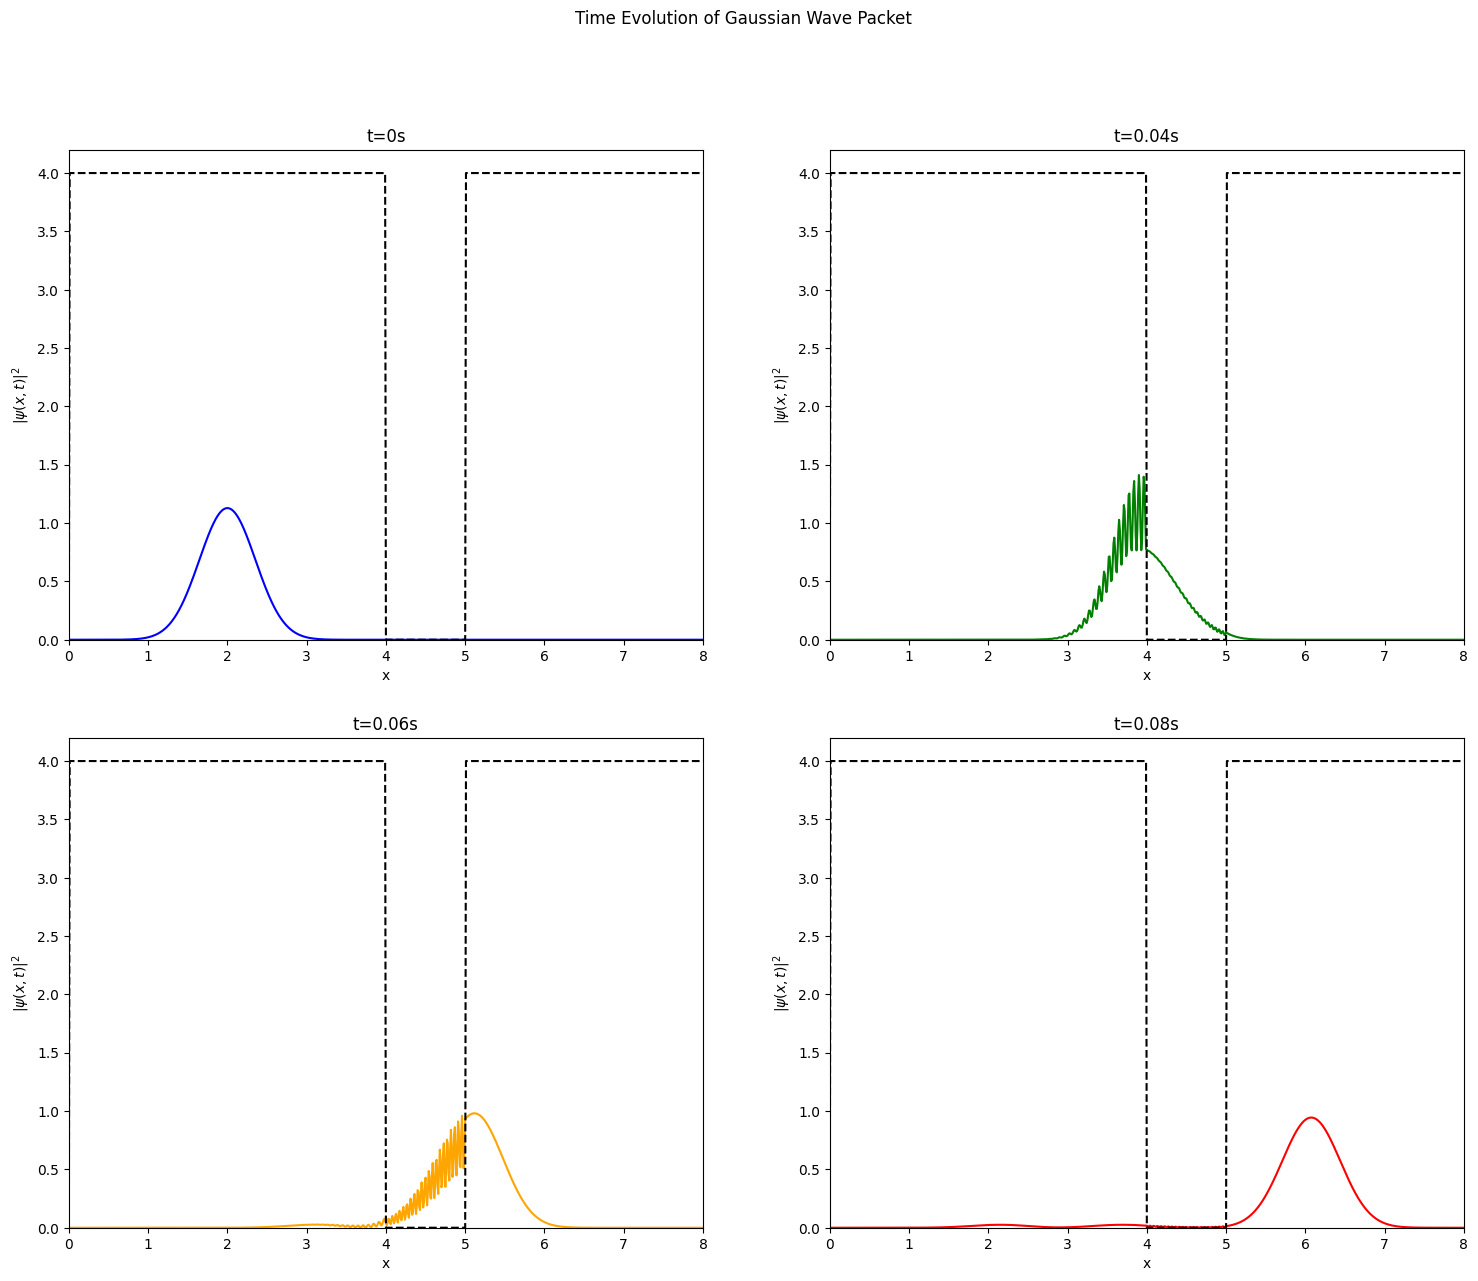

In [7]:
def V(x):
    V_hight = 1000
    V = np.zeros(x.shape)
    for i, _x in enumerate(x):
        if (_x > 0) & (_x < 4) | (_x > 5) & (_x < 10) :
            V[i] = V_hight
    return V
    
psi_initial=psi0(x)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))

plt.figure(figsize=(10,6))

times_to_plot = [0, 0.04, 0.06, 0.08]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple']

fig, axes = plt.subplots(2,2, figsize=(18, 14))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.004, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
    axes[i].set_xlim(x.min(), x.max())
    axes[i].set_ylim(0, 4.2)
fig.suptitle('Time Evolution of Gaussian Wave Packet')
#plt.legend()
plt.show()

# Double Potential Well 

$V(x) = \begin{cases} V_0, & \text{ if } 0 < x < a \\ 
                      0 , & \text{ if } a < x < b \\
                     V_0, & \text{ if } b < x < L \\
                     \infty & \text{otherwise} \end{cases} $

<Figure size 1000x600 with 0 Axes>

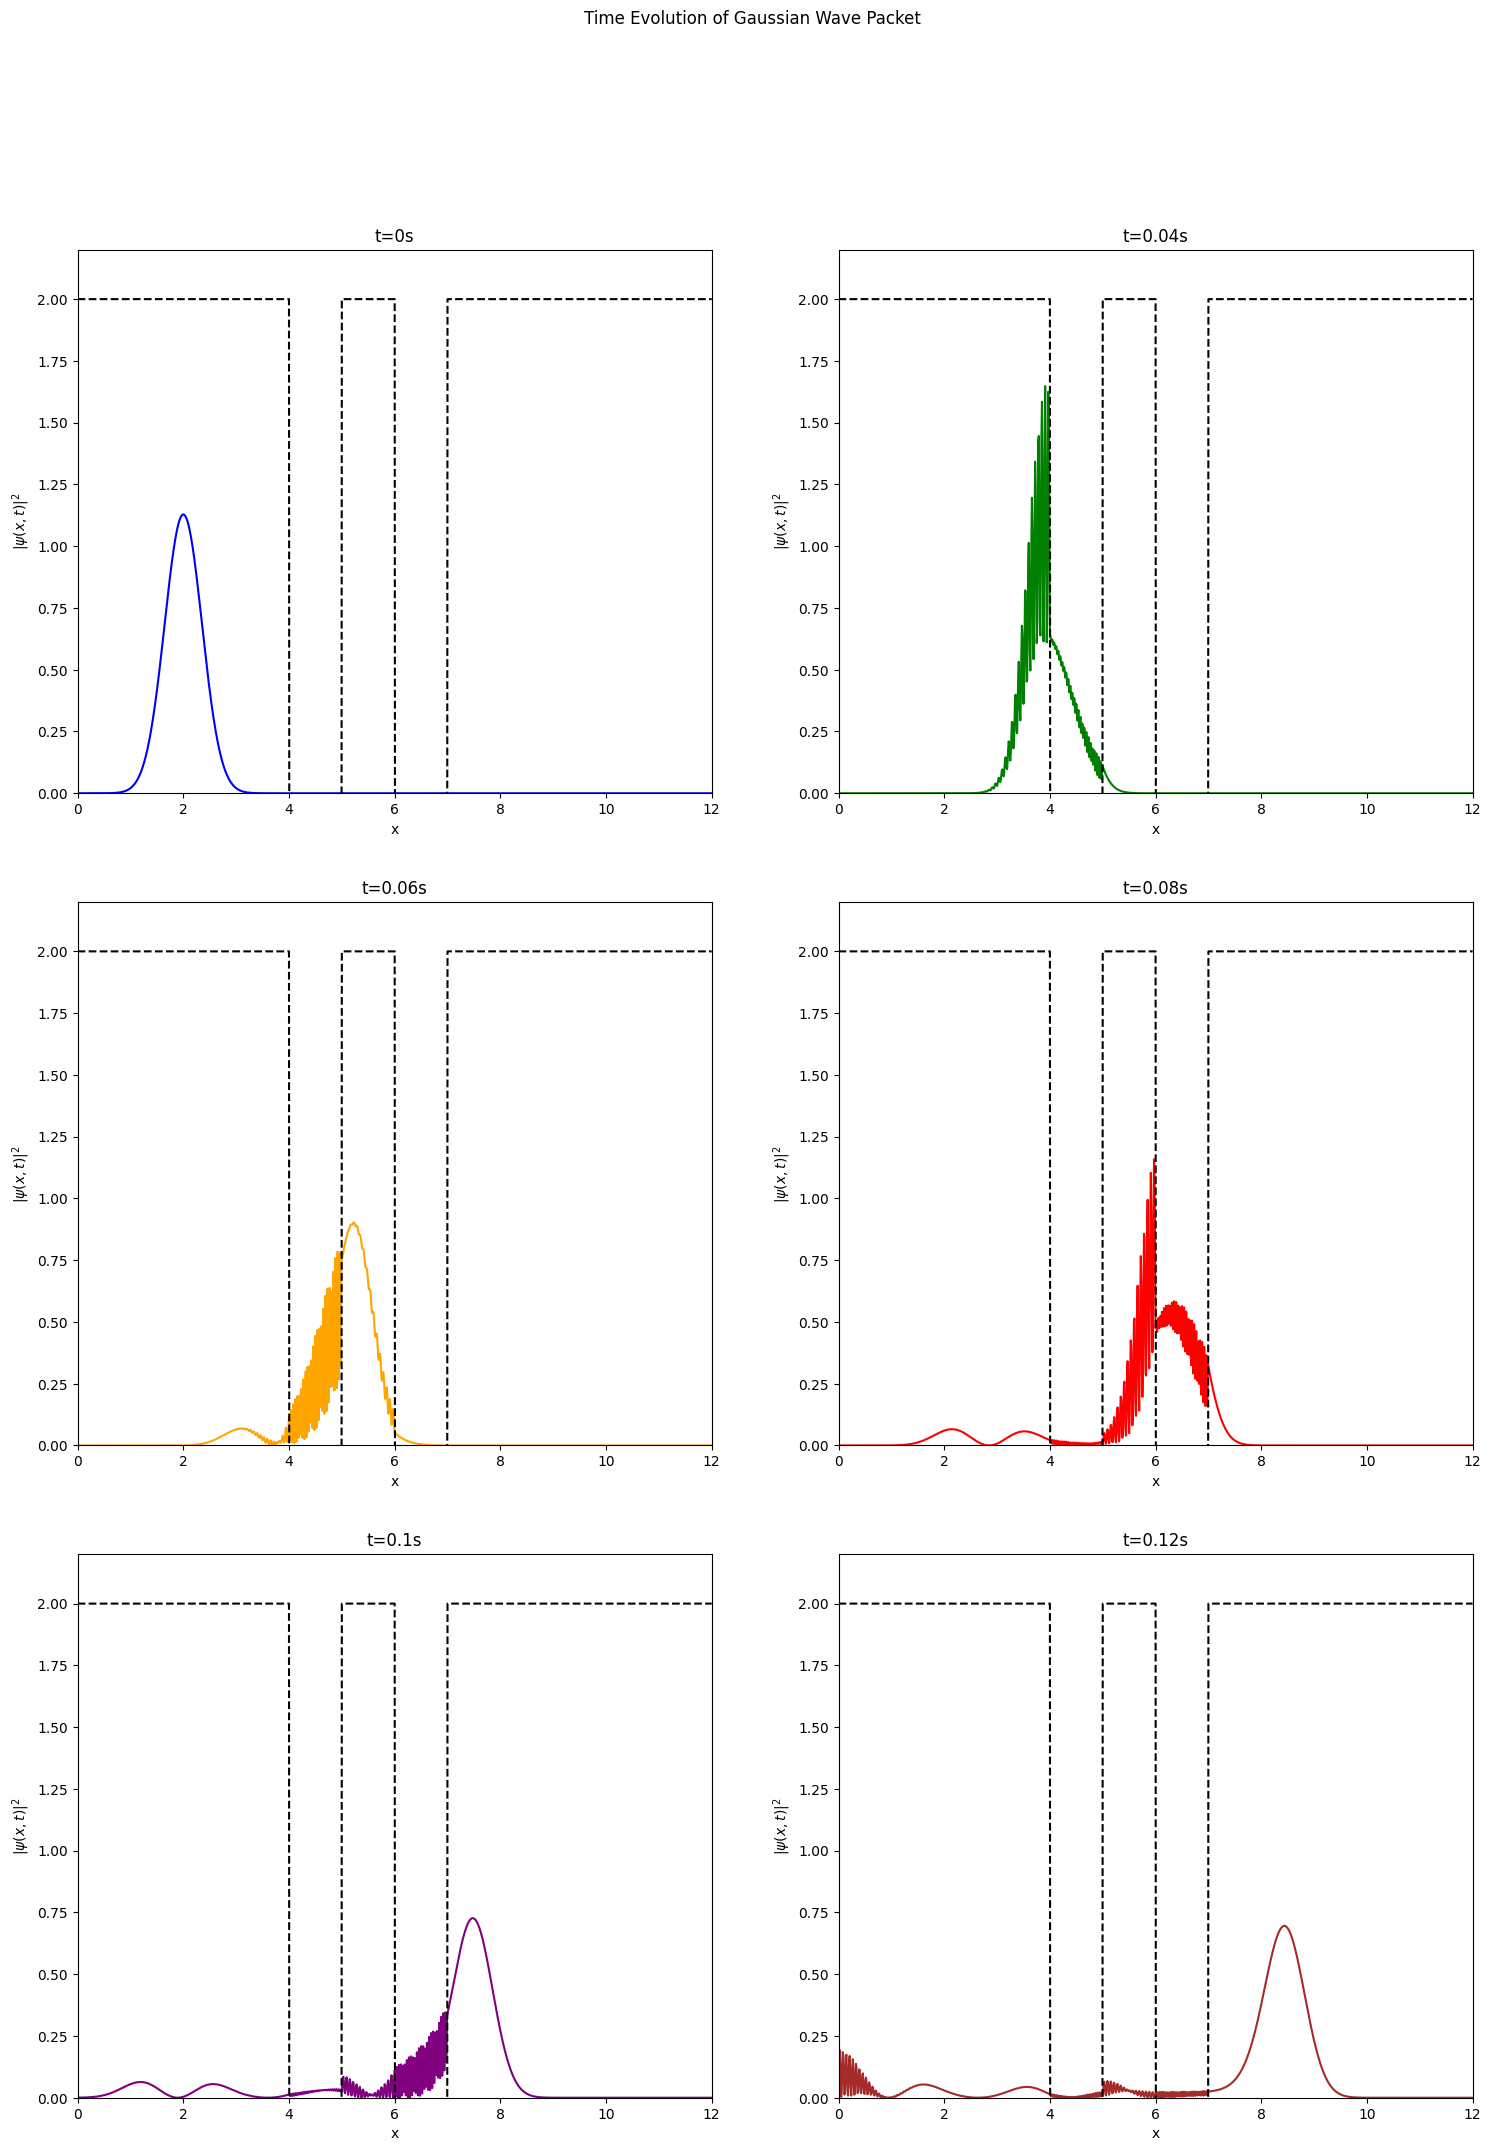

In [8]:
def V(x):
    V_hight = 1000
    V = np.zeros(x.shape)
    for i, _x in enumerate(x):
        V[i]= V_hight  
        if ((_x > 4) & (_x < 5))|((_x > 6) & (_x < 7)) :
            V[i] = - V_hight 
    return V

dx = 0.01
x_last = 12
x = np.arange(0, x_last + dx, dx)
psi_initial=psi0(x)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))

plt.figure(figsize=(10,6))

times_to_plot = [0, 0.04, 0.06, 0.08, 0.1, 0.12]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

fig, axes = plt.subplots(3,2, figsize=(18, 24))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.002, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
    axes[i].set_xlim(x.min(), x.max())
    axes[i].set_ylim(0, 2.2)
fig.suptitle('Time Evolution of Gaussian Wave Packet')
#plt.legend()
plt.show()

# Double Potential Barier

$V(x) = \begin{cases} 0, & \text{ if } 0 < x < a \\ 
                      V_0 , & \text{ if } a < x < b \\
                     0, & \text{ if } b < x < c \\
                     V_0, & \text{ if } c < x < L \\
                     \infty & \text{otherwise} \end{cases} $

<Figure size 1000x600 with 0 Axes>

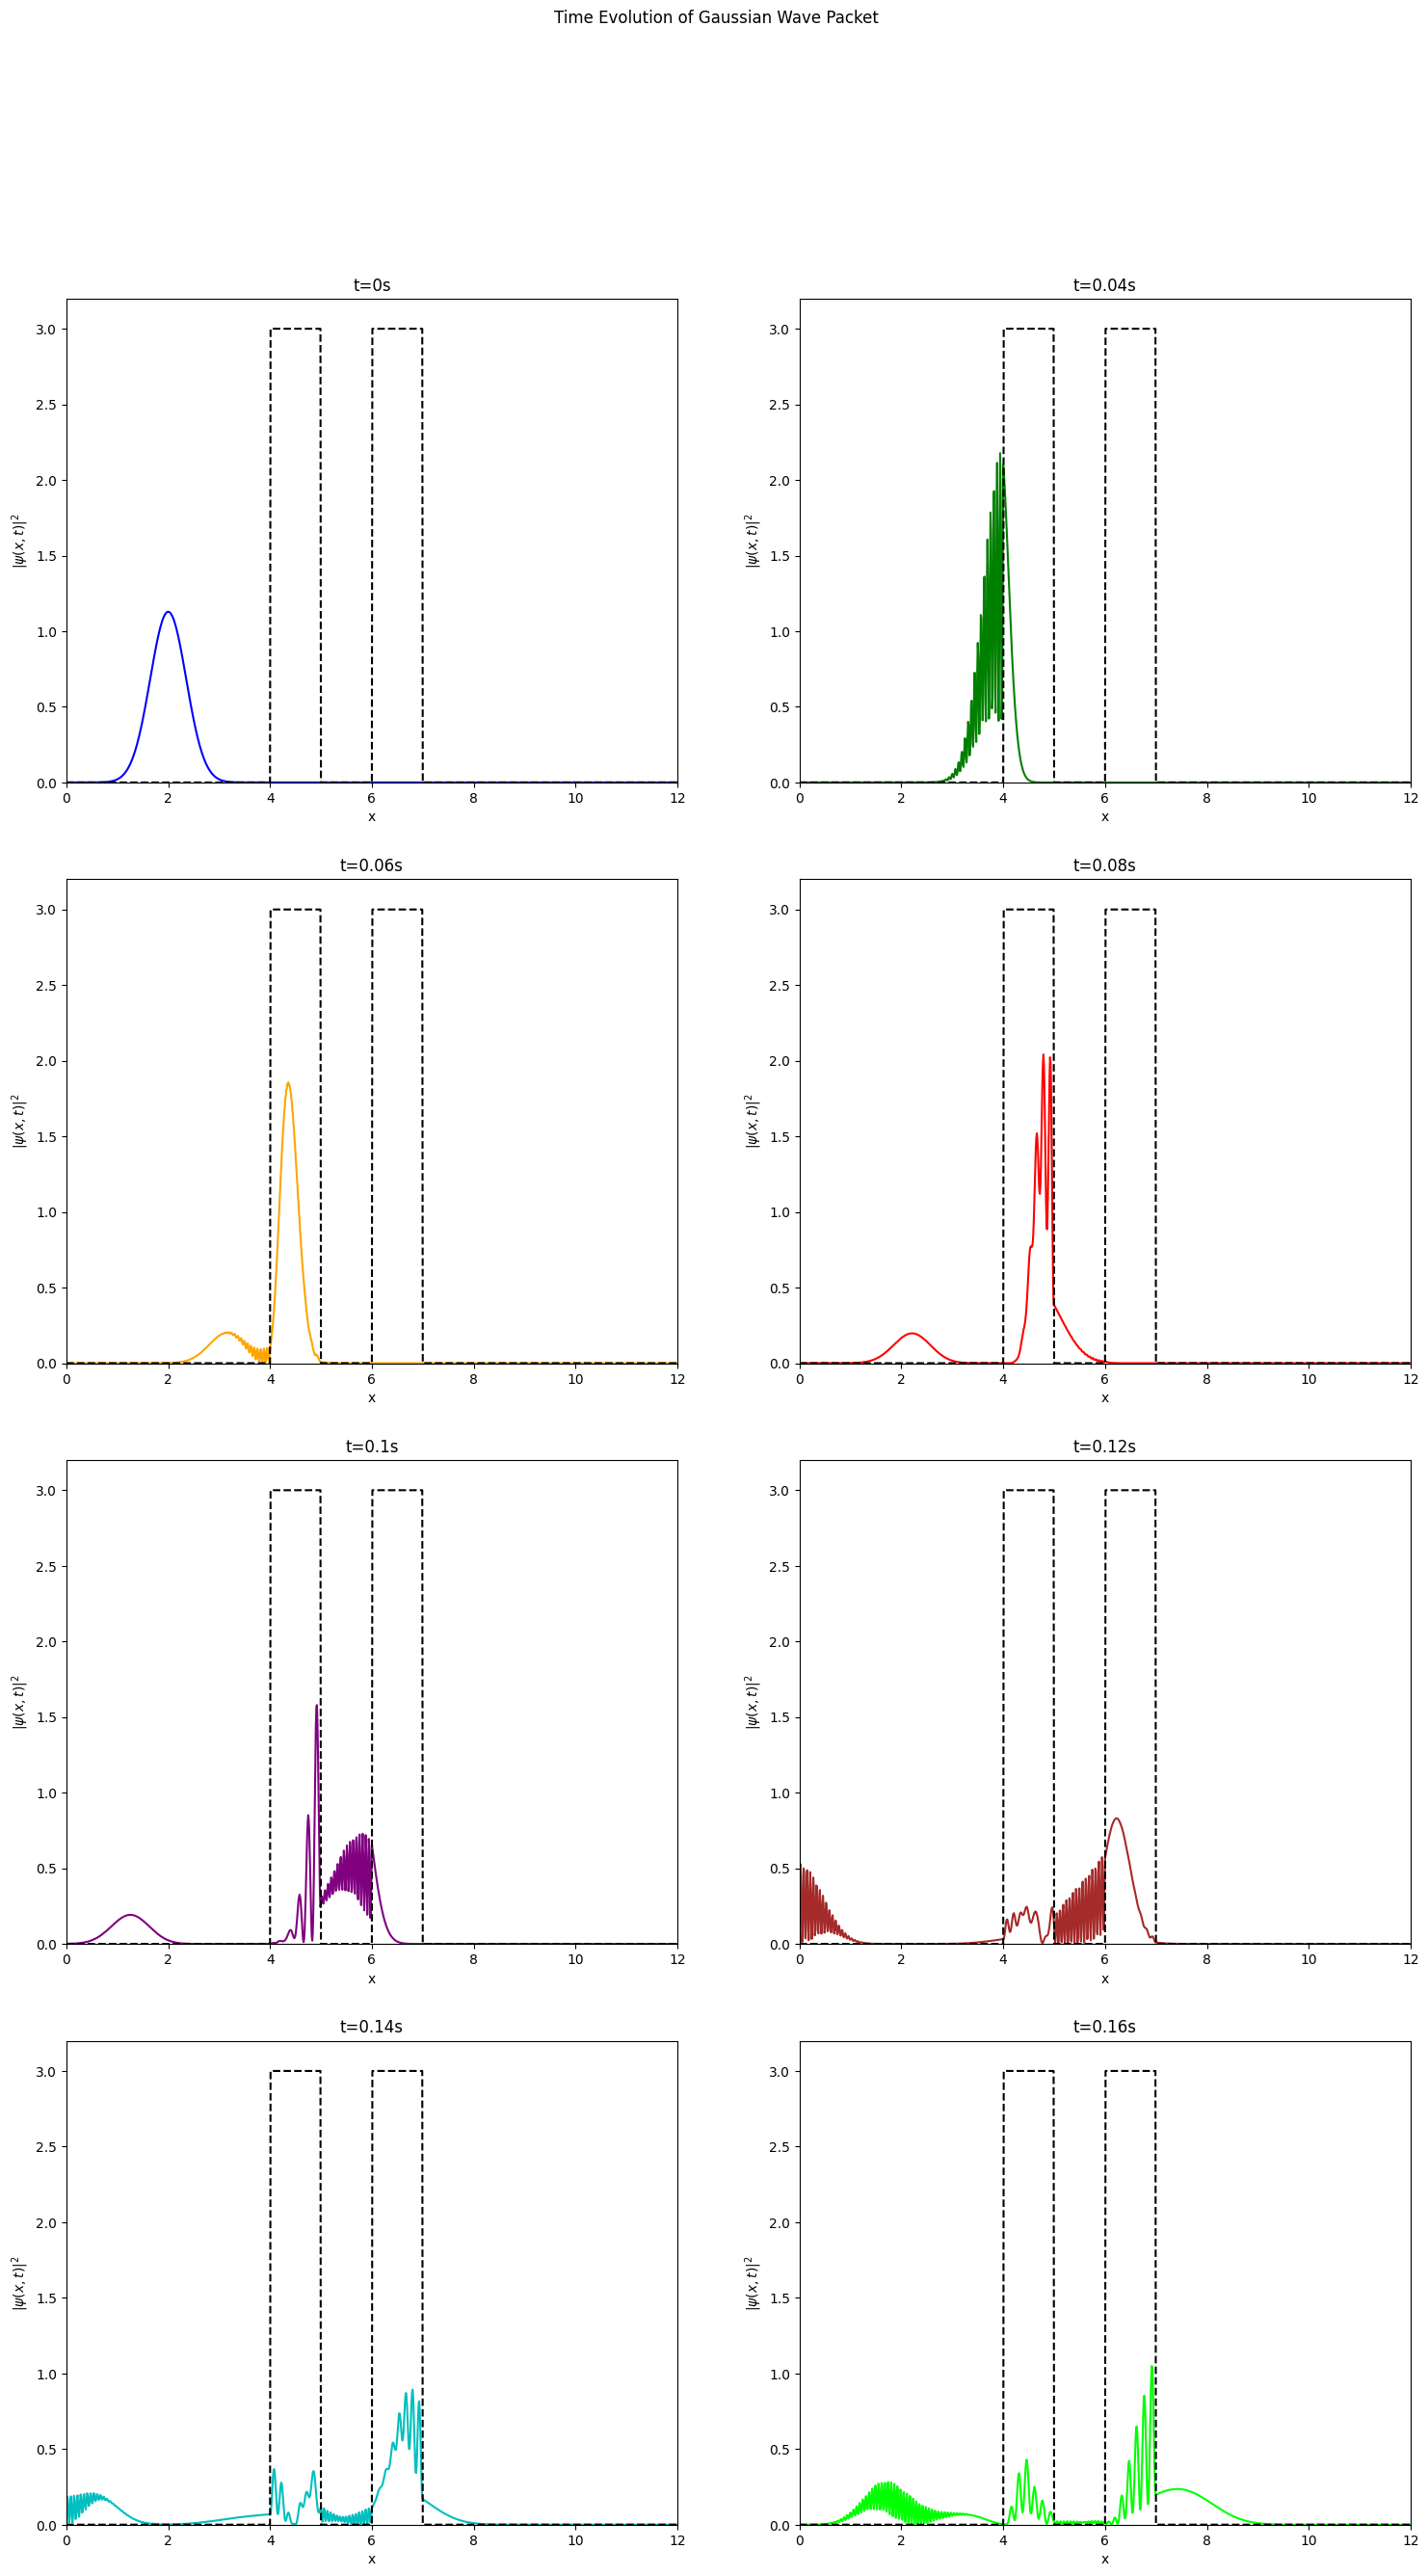

In [10]:
def V(x):
    V_hight = 1000
    V = np.zeros(x.shape)
    for i, _x in enumerate(x):
        if ((_x > 4) & (_x < 5))|((_x > 6) & (_x < 7)) :
           V[i] = V_hight
    return V


dx = 0.01
x_last = 12
x = np.arange(0, x_last + dx, dx)
psi_initial=psi0(x)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))

plt.figure(figsize=(10,6))

times_to_plot = [0, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'c', 'lime']

fig, axes = plt.subplots(4,2, figsize=(18, 30))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.003, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
    axes[i].set_xlim(x.min(), x.max())
    axes[i].set_ylim(0, 3.2)
fig.suptitle('Time Evolution of Gaussian Wave Packet')
#plt.legend()
plt.show()

# Quadratic Potential

$\qquad\displaystyle V=\frac{1}{2} k(x-x_0)^2$

<Figure size 1000x600 with 0 Axes>

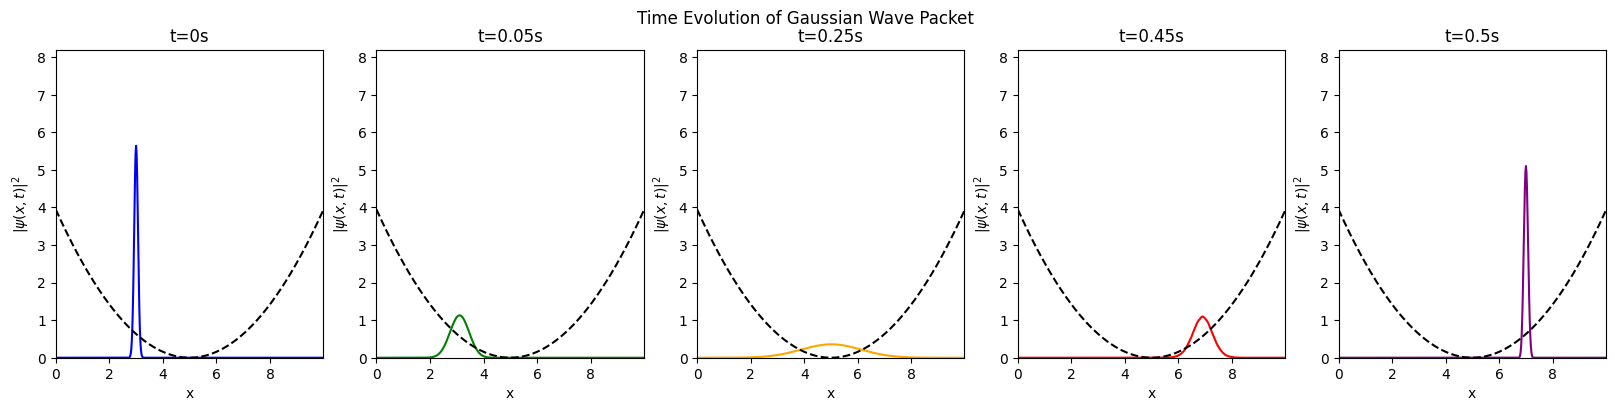

In [22]:
def V(x):
    x_Vmin = 5         # center of V(x)
    T      = 1           # peroid of SHO 
    omega = 2 * np.pi / T
    k = omega**2 * m
    return 0.5 * k * (x - x_Vmin)**2

dx    = 0.02                       # spatial separation
x     = np.arange(0, 10, dx)       # spatial grid points
kx     = 0.1                        # wave number
m      = 1                          # mass
sigma  = 0.1                        # width of initial gaussian wave-packet
x0     = 3.0                        # center of initial gaussian wave-packet
dt     = 0.05                       # time interval for snapshots
t0     = 0.0                        # initial time
tf     = 1.0                        # final time
t_eval = np.arange(t0, tf, dt)      # recorded time shots

psi_initial=psi0(x,kx,m,sigma,x0)
sol = integrate.solve_ivp(psi_t, t_span=[t0, tf], y0=psi_initial, t_eval=t_eval, method="RK23", args=(D2, V))

plt.figure(figsize=(10,6))

times_to_plot = [0, 0.05, 0.25, 0.45, 0.5]  # times in seconds
colors = ['blue', 'green', 'orange', 'red', 'purple']

fig, axes = plt.subplots(1,5, figsize=(20, 4))
axes = axes.flatten()
for i,(t, color) in enumerate(zip(times_to_plot, colors)):

    idx = (np.abs(t_eval - t)).argmin()  # closest time index
    axes[i].plot(x, np.abs(sol.y[:, idx])**2, color=color, label=f't={t:.2f}')
    axes[i].plot(x, V(x) * 0.008, "k--", label=r"$V(x)$")   # Plot Potential
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(r'$|\psi(x,t)|^2$')
    axes[i].set_title(f't={t}s')
    axes[i].set_xlim(x.min(), x.max())
    axes[i].set_ylim(0, 8.2)
fig.suptitle('Time Evolution of Gaussian Wave Packet')
#plt.legend()
plt.show()